# Data Preprocessing & EDA
Sprint Day 2-3 — ML Demand Forecasting Platform

Steps: load data → detect issues → clean → encode/scale → explore patterns → save cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/sales_dataset.csv", parse_dates=["date"])
print(df.shape)
df.head()

(36662, 7)


,date,store,product,price,promo,units_sold,revenue
0,2023-01-01,Store_1,Product_A,37.94,0,196.0,7417.96
1,2023-01-02,Store_1,Product_A,37.94,1,263.0,9964.37
2,2023-01-03,Store_1,Product_A,37.94,0,213.0,8083.12
3,2023-01-04,Store_1,Product_A,37.94,0,214.0,8102.63
4,2023-01-05,Store_1,Product_A,37.94,0,208.0,7878.38


## 1. Missing Value Detection

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
units_sold,367,1.0


**Handling:** `units_sold` is missing for ~1% of rows. Since sales are highly seasonal/grouped by store+product, we fill using the median for that store+product group rather than a global mean (a global fill would ignore that different products sell at very different volumes).

In [3]:
df["units_sold"] = df.groupby(["store", "product"])["units_sold"].transform(
    lambda s: s.fillna(s.median())
)
print("Remaining missing values:", df["units_sold"].isnull().sum())

Remaining missing values: 0


## 2. Duplicate Record Detection

In [4]:
dupe_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dupe_count}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dedup:", df.shape)

Exact duplicate rows: 182
Shape after dedup: (36480, 7)


## 3. Outlier Detection
Using the IQR method on `units_sold` per store+product group (a global IQR would flag high-volume products as 'outliers' just for being popular).

In [5]:
def flag_outliers_iqr(group):
    q1, q3 = group["units_sold"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (group["units_sold"] < lower) | (group["units_sold"] > upper)

df["is_outlier"] = df.groupby(["store", "product"], group_keys=False).apply(flag_outliers_iqr)
print(f"Outliers flagged: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}% of rows)")

# Keep outliers but flagged (don't blindly drop — some are real demand spikes/promo effects,
# not data errors. Dropping them would hide genuine anomalies you may want to model separately.)
df[df["is_outlier"]].head()

Outliers flagged: 372 (1.02% of rows)


,date,store,product,price,promo,units_sold,revenue,is_outlier
107,2023-04-18,Store_1,Product_A,37.94,1,286.0,10844.47,True
329,2023-11-26,Store_1,Product_A,37.94,0,637.0,24174.74,True
531,2024-06-15,Store_1,Product_A,37.94,0,20.0,765.26,True
632,2024-09-24,Store_1,Product_A,37.94,0,19.0,712.67,True
772,2025-02-11,Store_1,Product_A,37.94,1,295.0,11185.36,True


## 4. Feature Encoding

In [6]:
le_store = LabelEncoder()
le_product = LabelEncoder()
df["store_encoded"] = le_store.fit_transform(df["store"])
df["product_encoded"] = le_product.fit_transform(df["product"])

# Date-derived features (useful for tree-based models in the next stage)
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df.head()

,date,store,product,price,promo,units_sold,revenue,is_outlier,store_encoded,product_encoded,day_of_week,month,year,is_weekend
0,2023-01-01,Store_1,Product_A,37.94,0,196.0,7417.96,False,0,0,6,1,2023,1
1,2023-01-02,Store_1,Product_A,37.94,1,263.0,9964.37,False,0,0,0,1,2023,0
2,2023-01-03,Store_1,Product_A,37.94,0,213.0,8083.12,False,0,0,1,1,2023,0
3,2023-01-04,Store_1,Product_A,37.94,0,214.0,8102.63,False,0,0,2,1,2023,0
4,2023-01-05,Store_1,Product_A,37.94,0,208.0,7878.38,False,0,0,3,1,2023,0


## 5. Feature Scaling

In [7]:
scaler = StandardScaler()
df[["price_scaled", "units_sold_scaled"]] = scaler.fit_transform(df[["price", "units_sold"]])
df[["price", "price_scaled", "units_sold", "units_sold_scaled"]].head()

,price,price_scaled,units_sold,units_sold_scaled
0,37.94,0.679681,196.0,0.647402
1,37.94,0.679681,263.0,1.711689
2,37.94,0.679681,213.0,0.917445
3,37.94,0.679681,214.0,0.933330
4,37.94,0.679681,208.0,0.838020


## 6. EDA — Distributions

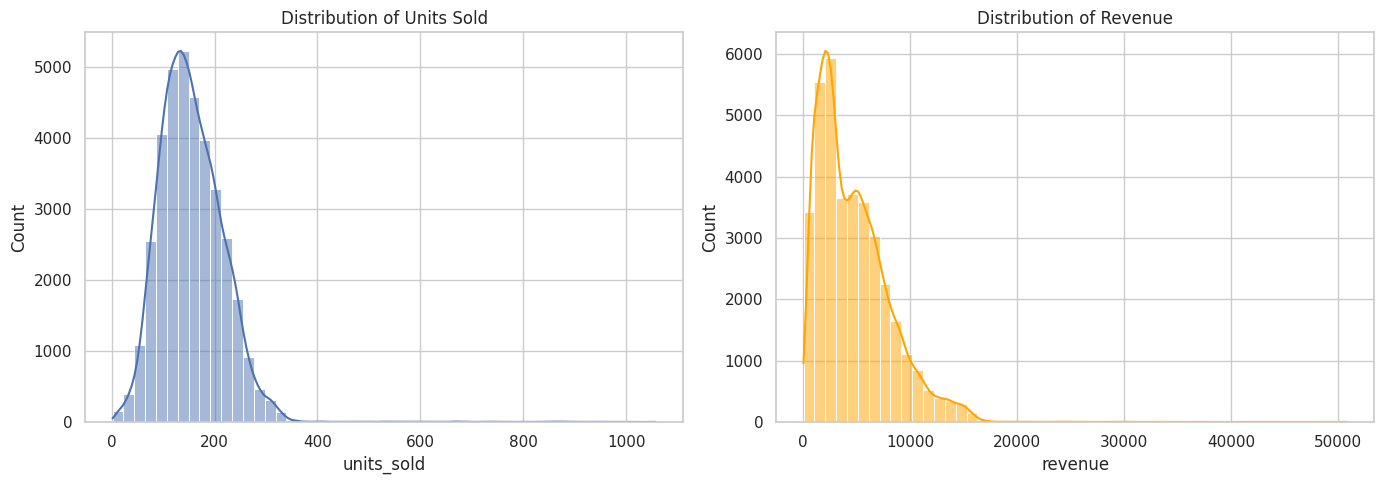

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["units_sold"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Units Sold")
sns.histplot(df["revenue"], bins=50, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Revenue")
plt.tight_layout()
plt.savefig("../docs/eda_distributions.png", dpi=120)
plt.show()

## 7. EDA — Correlation Matrix

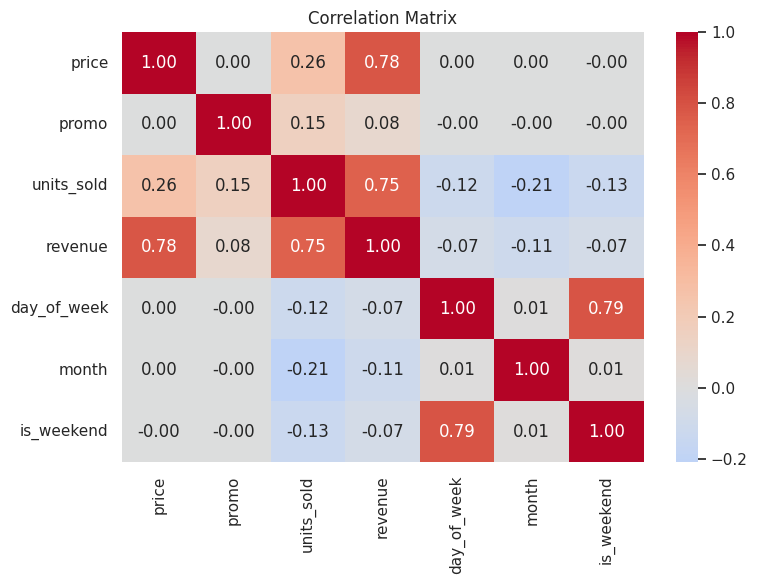

In [9]:
numeric_cols = ["price", "promo", "units_sold", "revenue", "day_of_week", "month", "is_weekend"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/eda_correlation_matrix.png", dpi=120)
plt.show()

## 8. EDA — Trend Over Time

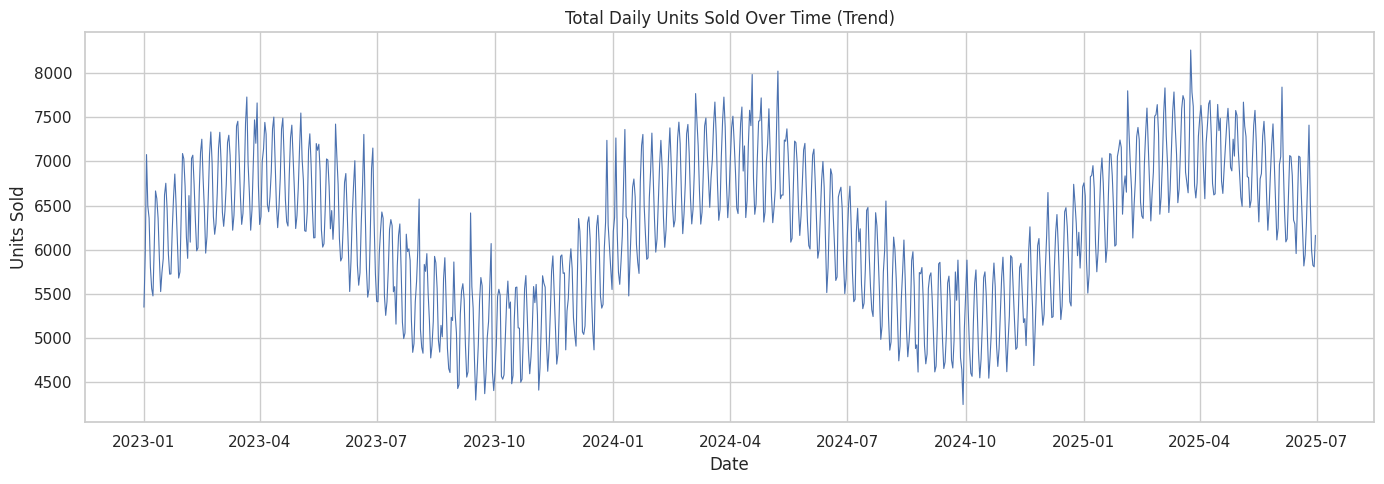

In [10]:
daily_sales = df.groupby("date")["units_sold"].sum().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["units_sold"], linewidth=0.8)
plt.title("Total Daily Units Sold Over Time (Trend)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.savefig("../docs/eda_trend.png", dpi=120)
plt.show()

## 9. EDA — Weekly & Yearly Seasonality

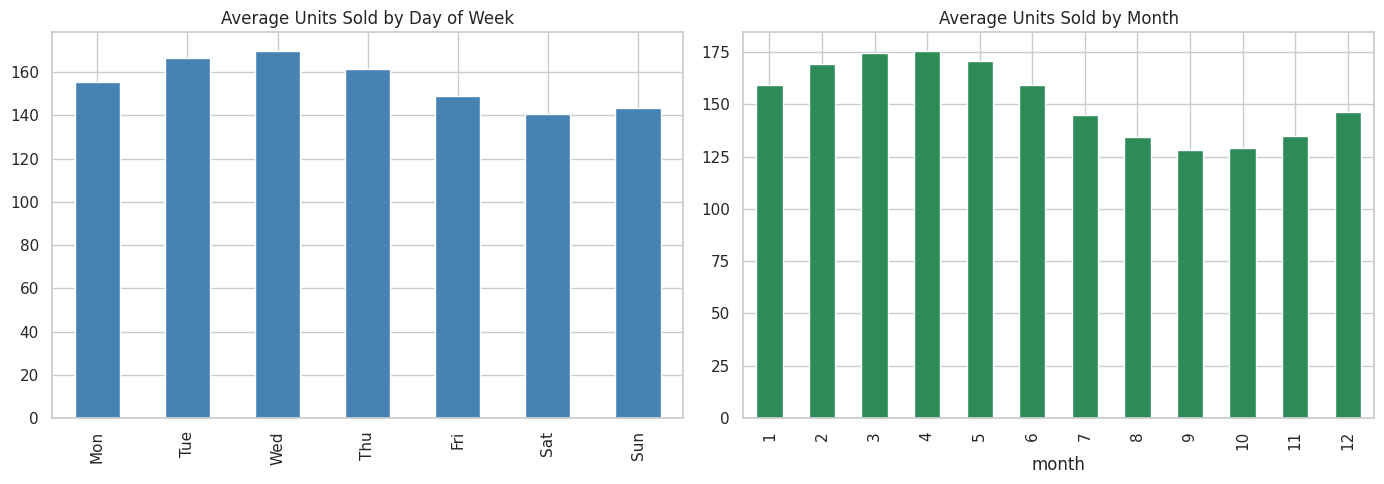

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weekly = df.groupby("day_of_week")["units_sold"].mean()
weekly.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Average Units Sold by Day of Week")

monthly = df.groupby("month")["units_sold"].mean()
monthly.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Average Units Sold by Month")

plt.tight_layout()
plt.savefig("../docs/eda_seasonality.png", dpi=120)
plt.show()

## 10. EDA — Store & Product Comparison

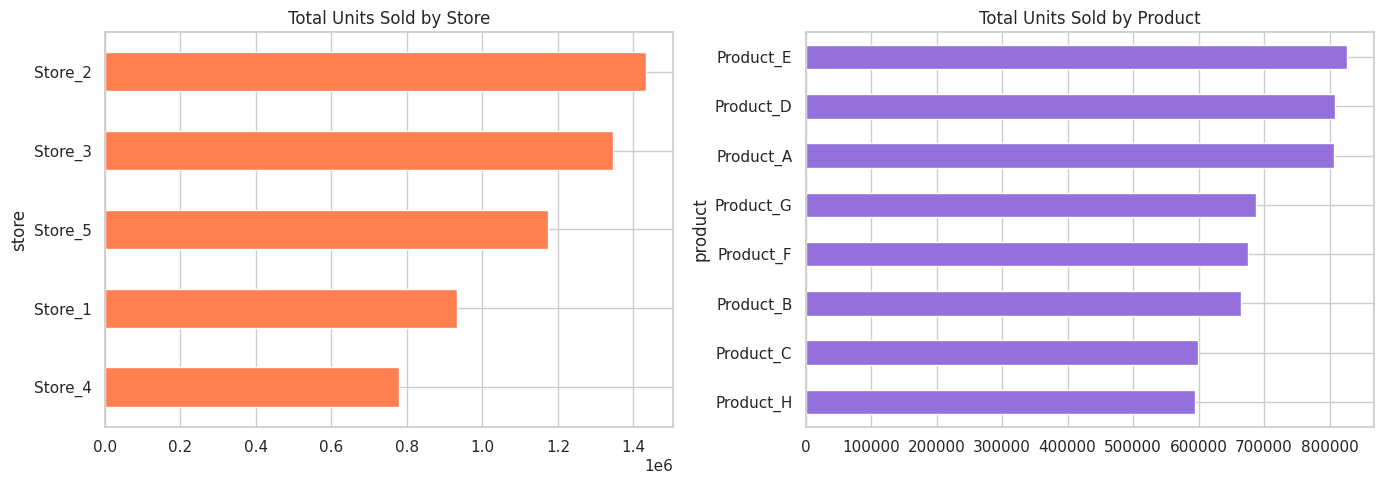

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("store")["units_sold"].sum().sort_values().plot(kind="barh", ax=axes[0], color="coral")
axes[0].set_title("Total Units Sold by Store")

df.groupby("product")["units_sold"].sum().sort_values().plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Total Units Sold by Product")

plt.tight_layout()
plt.savefig("../docs/eda_store_product.png", dpi=120)
plt.show()

## 11. Promo Effect

In [13]:
promo_effect = df.groupby("promo")["units_sold"].mean()
print(promo_effect)
lift_pct = (promo_effect[1] / promo_effect[0] - 1) * 100
print(f"Promo lift: {lift_pct:.1f}% higher average sales during promos")

promo
0    152.420431
1    186.906093
Name: units_sold, dtype: float64
Promo lift: 22.6% higher average sales during promos


## 12. Save Cleaned Dataset

In [14]:
cleaned = df.drop(columns=["price_scaled", "units_sold_scaled"])  # keep raw + engineered features,
                                                                    # scaling is redone per-model in Day 4-5
cleaned.to_csv("../data/cleaned_sales_dataset.csv", index=False)
print("Saved:", cleaned.shape)
cleaned.head()

Saved: (36480, 14)


,date,store,product,price,promo,units_sold,revenue,is_outlier,store_encoded,product_encoded,day_of_week,month,year,is_weekend
0,2023-01-01,Store_1,Product_A,37.94,0,196.0,7417.96,False,0,0,6,1,2023,1
1,2023-01-02,Store_1,Product_A,37.94,1,263.0,9964.37,False,0,0,0,1,2023,0
2,2023-01-03,Store_1,Product_A,37.94,0,213.0,8083.12,False,0,0,1,1,2023,0
3,2023-01-04,Store_1,Product_A,37.94,0,214.0,8102.63,False,0,0,2,1,2023,0
4,2023-01-05,Store_1,Product_A,37.94,0,208.0,7878.38,False,0,0,3,1,2023,0


## Summary of Findings
- Missing values: filled per store+product group median (not a global fill)
- Duplicates: removed exact-match duplicate rows
- Outliers: flagged (not dropped) using per-group IQR — likely promo spikes or the injected anomalies
- Strong weekly seasonality (weekday dip, weekend lift) and yearly seasonality visible in the trend plot
- Promo days show a clear sales lift — worth including as a model feature
- Dataset is now clean, encoded, and feature-engineered — ready for Day 4-5 model development